# City Workflow — TerrainSession

End-to-end city workflow using the session SDK:

1. Start server & select a city-scale region
2. Fetch DEM + city data
3. Composite city raster (buildings, roads, waterways, walls)
4. Rasterize city (merged height deltas)
5. Visualize layers
6. Export city 3MF
7. Full pipeline with `run_all()`

Docs: [sdk-workflow.md](../docs/sdk-workflow.md) · [api.md](../docs/api.md)

In [1]:
%matplotlib inline

In [2]:
import sys, os
os.chdir(os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))
sys.path.insert(0, os.path.abspath(".."))

from app.session.terrain_session import TerrainSession

No OpenTopography API key found. Set the OPENTOPO_API_KEY environment variable to enable DEM downloads.


## 1. Start Server & Select Region

In [3]:
s = TerrainSession(port=9090)
s.start(visible=True)

Server already running at http://127.0.0.1:9090
  (use s.start(force_restart=True) or s.restart() to force reload)


In [4]:
# List available regions — pick one with city-scale bbox
s.regions()

,name,continent,source,city,north,south,east,west
0,ADKs,None,None,None,44.4167,43.9583,-73.6667,-74.2492
1,Aegean,None,None,None,43.0000,34.0000,30.9000,18.6000
2,Amazon,None,None,None,15.0000,-19.0000,-45.0000,-85.0000
3,Amsterdam_eval,None,None,None,52.3800,52.3550,4.9200,4.8800
4,Appalachia,None,None,None,50.0000,32.0000,-64.0000,-88.0000
...,...,...,...,...,...,...,...,...
116,Yosemite,None,None,None,37.8750,37.6250,-119.4167,-119.6667
117,YosemiteBig,None,None,None,38.0000,37.6250,-119.2917,-119.6667
118,Zion National Park,None,None,None,37.9167,37.0833,-112.5000,-113.3333
119,Zion National Park_2,None,None,None,37.5000,37.0833,-112.6667,-113.1667


Showing 121 regions


,name,continent,source,city,north,south,east,west
0,ADKs,None,None,None,44.4167,43.9583,-73.6667,-74.2492
1,Aegean,None,None,None,43.0000,34.0000,30.9000,18.6000
2,Amazon,None,None,None,15.0000,-19.0000,-45.0000,-85.0000
3,Amsterdam_eval,None,None,None,52.3800,52.3550,4.9200,4.8800
4,Appalachia,None,None,None,50.0000,32.0000,-64.0000,-88.0000
...,...,...,...,...,...,...,...,...
116,Yosemite,None,None,None,37.8750,37.6250,-119.4167,-119.6667
117,YosemiteBig,None,None,None,38.0000,37.6250,-119.2917,-119.6667
118,Zion National Park,None,None,None,37.9167,37.0833,-112.5000,-113.3333
119,Zion National Park_2,None,None,None,37.5000,37.0833,-112.6667,-113.1667


In [22]:
# 
s.select("Cartagena")

# Configure settings for city work
s.settings["dem"]["dim"] = 600
s.settings["projection"]["projection"] = "sinusoidal"  # or "sinusoidal"

# City-specific settings
s.settings["city"]["building_scale"] = 0.5
s.settings["city"]["road_depression_m"] = 3.0
s.settings["city"]["water_depression_m"] = 5.0

s.settings_table()

Region : Cartagena
BBox   : {'north': 10.4295, 'south': 10.3845, 'east': -75.5221, 'west': -75.5679}
── projection ──


,value
clip_nans,True
maintain_dimensions,False
projection,sinusoidal


── dem ──


,value
dem_source,local
depth_scale,0.5
dim,600
show_sat,False
subtract_water,True
water_scale,0.05


── export ──


...

,value
building_scale,0.5
layers,"['buildings', 'roads', 'waterways']"
min_area,5
road_depression_m,3.0
simplify_terrain,True
simplify_tolerance,0.5
water_depression_m,5.0


── view ──


,value
colormap,rainbow
elevation_curve,linear
elevation_curve_points,"[[0, 0], [0.4758213362864526, 0.47582133628645..."
gridlines_count,5
gridlines_show,True
rescale_max,193
rescale_min,-70


── hydrology ──


,value
depression_m,-5
dim,300
min_order,3
order_exponent,1.5
scale_m,10
source,hydrorivers


## 2. Fetch DEM

c:\Users\eac84\OneDrive\Documents\Projects\3D Maps\Code\strm2stl\app\session\terrain_session.py:1180: UserWarning: settings['view']['colormap'] = 'rainbow' is not in the known list ['RdBu', 'cividis', 'gray', 'hot', 'inferno', 'magma', 'ocean', 'plasma', 'terrain', 'viridis']. It will work if it is a valid matplotlib colormap name, but may not render correctly in the UI.
  self._ensure_available_for_fetch("DEM")


Fetching DEM…
min=-57.9 m  max=70.9 m  mean=-4.6 m  shape=[600, 590]
shape=(600, 590)  min=-6.9  max=8.5


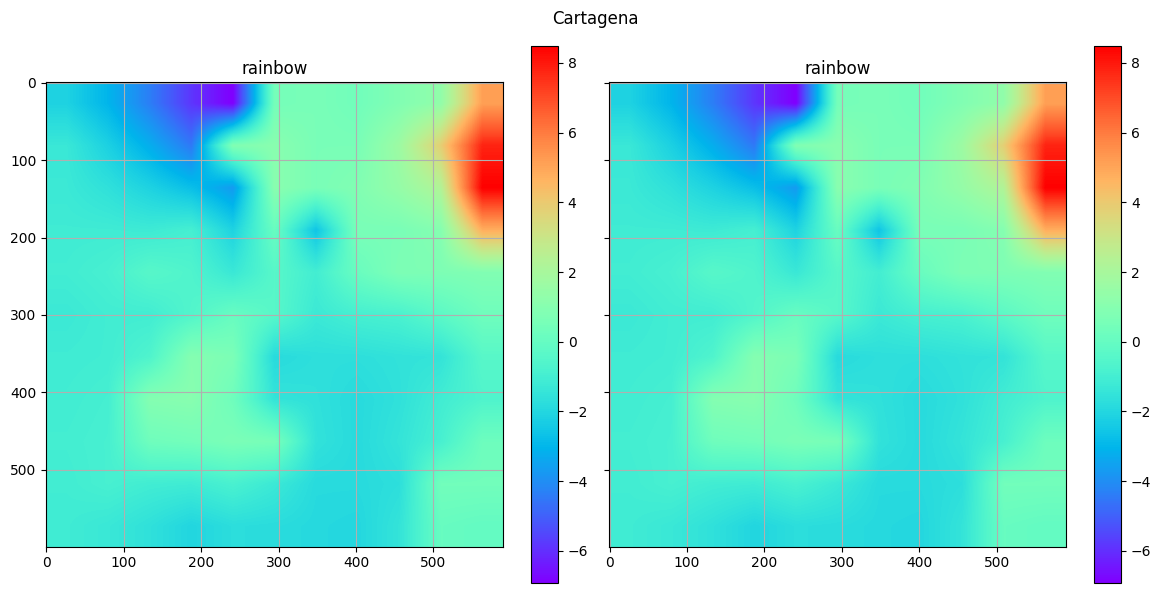

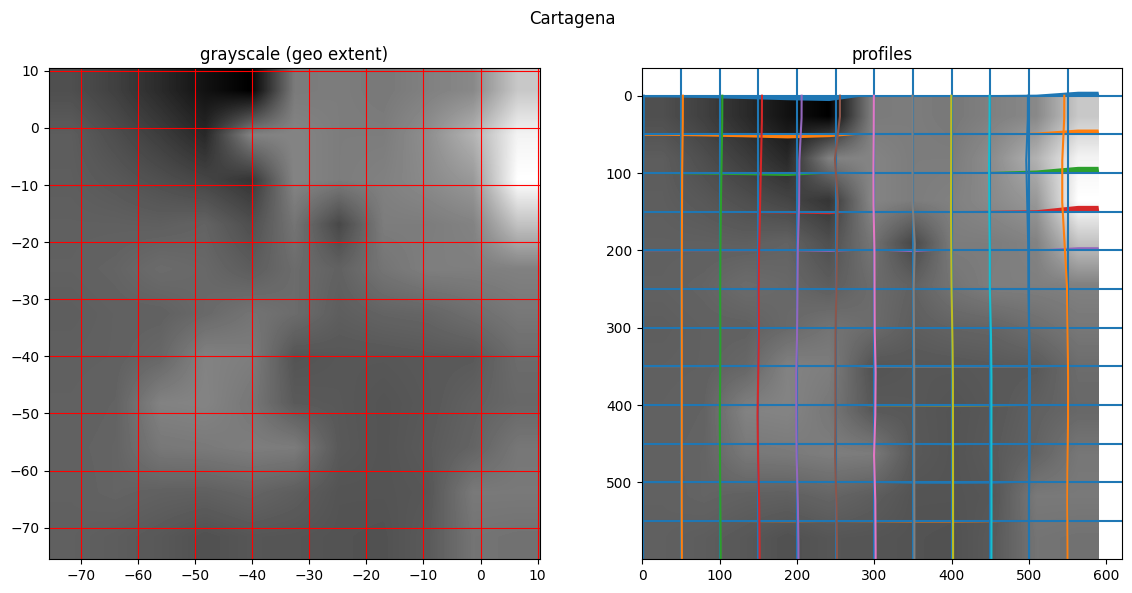

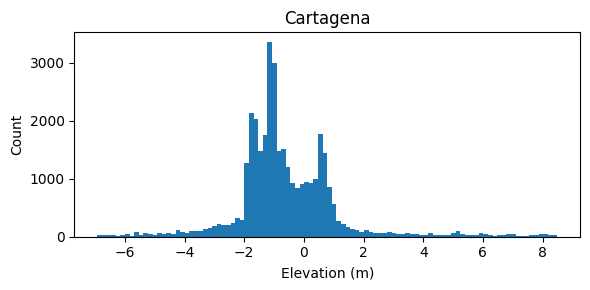

In [23]:
s.fetch_dem()
s.show_dem()

## 3. Fetch City Data (OSM buildings, roads, waterways)

In [24]:
# Check if city data is already cached
cached = s.check_city_cache()
print(f"Cached: {cached}")

City cache: hit ✓
Cached: True


In [25]:
# Fetch OSM data (uses cache if available)
s.fetch_cities()

# Quick summary of what was fetched
if s.city_data:
    for layer in ["buildings", "roads", "waterways"]:
        feats = s.city_data.get(layer, {}).get("features", [])
        print(f"  {layer}: {len(feats)} features")

Fetching OSM city data (bbox: 7.1 km diagonal)…
✓ Fetched 3015 buildings, 1803 roads, 69 waterways
  buildings: 3015 features
  roads: 1803 features
  waterways: 69 features


## 4. Composite City Raster (per-layer arrays)

City raster: 590×600 px, layers: buildings, roads, waterways, walls (projected: sinusoidal)


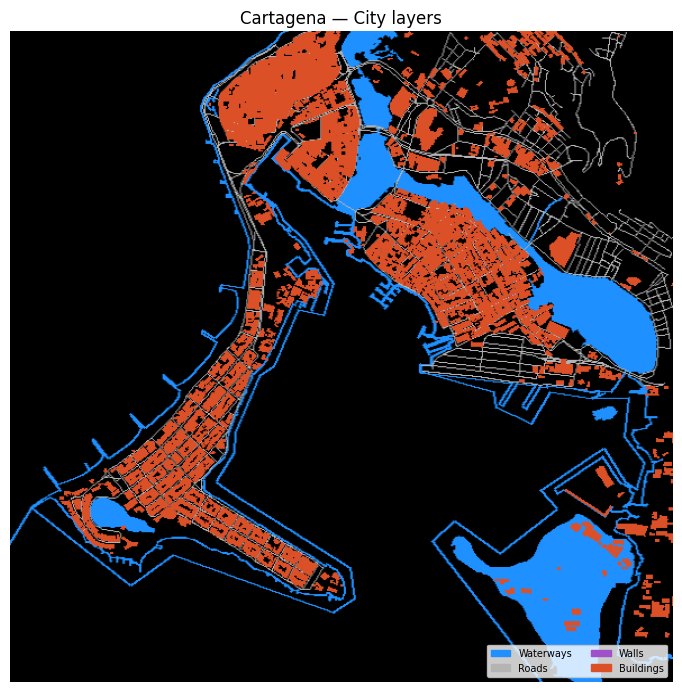

In [26]:
# Rasterize from disk cache — returns separate arrays for buildings, roads,
# waterways, and walls.  Projection is applied server-side.
s.composite_city_raster()
s.show_city()

## 5. Rasterize City (merged height-delta grid)

In [27]:
# Alternative: single merged height map compatible with merge_dem()
s.rasterize_city()

ERROR 422: {"detail":[{"type":"dict_type","loc":["body","buildings"],"msg":"Input should be a valid dictionary","input":true},{"type":"dict_type","loc":["body","roads"],"msg":"Input should be a valid dictionary","input":true},{"type":"dict_type","loc":["body","waterways"],"msg":"Input should be a valid dictionary","input":true}]}


HTTPError: 422 Client Error: Unprocessable Entity for url: http://127.0.0.1:9090/api/cities/raster

## 6. Export City 3MF

In [28]:
# Export terrain + extruded buildings as 3MF
data_3mf = s.export_city_3mf()

# Save to disk
out_path = os.path.join("output", "city_export.3mf")
os.makedirs("output", exist_ok=True)
with open(out_path, "wb") as f:
    f.write(data_3mf)
print(f"Saved to {out_path}")

Exporting city 3MF for Cartagena…
ERROR 400: {"error":"DEM not found in cache — load DEM first"}


HTTPError: 400 Client Error: Bad Request for url: http://127.0.0.1:9090/api/cities/export3mf

## 7. Full Pipeline

For the standard terrain-only pipeline, use `run_all()`.
For terrain + city, chain the steps manually:

In [ ]:
# Terrain + city pipeline (chain)
s.select("StatenIsland")
s.fetch_dem()
s.fetch_cities()
s.composite_city_raster()
s.show_dem()
s.show_city()

## 8. Cleanup

In [ ]:
s.stop()